# <center> 📰 ☣ ⚕   <font color = 'blue'>**Transformer-based biomedical text condensation**</font></center>

In [1]:
#Install dependencies
!pip install -q transformers==4.41.2 datasets evaluate accelerate rouge_score sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 53.1 MB/s eta 0:00:00


In [2]:
# Imports principales
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import evaluate
import numpy as np
import re

# Verificar GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [3]:
# Métrica ROUGE
rouge = evaluate.load("rouge")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
# Cargar dataset (subset para trabajar más rápido)
dataset = load_dataset("ccdv/pubmed-summarization", split="train[:1%]")

# Ver estructura
print(dataset)

# Tomar un ejemplo
sample = dataset[0]

print("Keys:", sample.keys())
print("\n--- ARTICLE ---\n")
print(sample["article"][:1000])
print("\n--- ABSTRACT ---\n")
print(sample["abstract"])

README.md: 0.00B [00:00, ?B/s]

section/train-00000-of-00005.parquet:   0%|          | 0.00/210M [00:00<?, ?B/s]

section/train-00001-of-00005.parquet:   0%|          | 0.00/208M [00:00<?, ?B/s]

section/train-00002-of-00005.parquet:   0%|          | 0.00/207M [00:00<?, ?B/s]

section/train-00003-of-00005.parquet:   0%|          | 0.00/211M [00:00<?, ?B/s]

...

section/test-00000-of-00001.parquet:   0%|          | 0.00/58.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/119924 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6633 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6658 [00:00<?, ? examples/s]

Dataset({
    features: ['article', 'abstract'],
    num_rows: 1199
})
Keys: dict_keys(['article', 'abstract'])

--- ARTICLE ---

a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5 years were mildly , moderately or severely stunted and 258 ( 240 - 274 ) million were mildly , moderately or severely underweight in the developing countries . 
 in iran a study among 752 high school girls in sistan and baluchestan showed prevalence of 16.2% , 8.6% and 1.5% , for underweight , overweight and obesity , respectively . 
 the prevalence of malnutrition among elementary school aged children in tehran varied from 6% to 16% . 
 anthropometric study of elementary school students in shiraz revealed that 16% of them suffer from malnutrition and low body weight . 
 snack should have 300 - 400 kcal energy and could provide 5 - 10 g of protein / day . nowadays , school nutrition programs are running as the national programs , world - wide . national schoo

In [5]:
#Select subset
#dataset_small = dataset["train"].shuffle(seed=42).select(range(1000))


In [6]:
#cleaning

def clean_text(text):
    if not isinstance(text, str):
        text = " ".join(text) if isinstance(text, list) else str(text)

    text = text.replace("\n", " ")
    text = re.sub(r"\[\d+\]", "", text)      # remove citations [1]
    text = re.sub(r"\s+", " ", text)         # collapse spaces
    text = re.sub(r"\s+([.,;:])", r"\1", text)  # fix space before punctuation

    return text.strip()

def preprocess(example):
    return {
        "article": clean_text(example["article"]),
        "abstract": clean_text(example["abstract"])
    }

# Apply preprocessing
dataset = dataset.map(preprocess)

Map:   0%|          | 0/1199 [00:00<?, ? examples/s]

In [7]:
# Inspect result
sample = dataset[0]
print("ARTICLE:\n", sample["article"][:500])
print("\nABSTRACT:\n", sample["abstract"])

ARTICLE:
 a recent systematic analysis showed that in 2011, 314 ( 296 - 331 ) million children younger than 5 years were mildly, moderately or severely stunted and 258 ( 240 - 274 ) million were mildly, moderately or severely underweight in the developing countries. in iran a study among 752 high school girls in sistan and baluchestan showed prevalence of 16.2%, 8.6% and 1.5%, for underweight, overweight and obesity, respectively. the prevalence of malnutrition among elementary school aged children in teh

ABSTRACT:
 background: the present study was carried out to assess the effects of community nutrition intervention based on advocacy approach on malnutrition status among school - aged children in shiraz, iran.materials and methods: this case - control nutritional intervention has been done between 2008 and 2009 on 2897 primary and secondary school boys and girls ( 7 - 13 years old ) based on advocacy approach in shiraz, iran. the project provided nutritious snacks in public schools 

token-based chunking

In [8]:

# Shared tokenizer for chunking (model-agnostic)
chunk_tokenizer = AutoTokenizer.from_pretrained("facebook/bart-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
def chunk_text(text, tokenizer, max_tokens=1024, overlap=50, min_tokens=50):
    tokens = tokenizer.encode(text, add_special_tokens=False, truncation=False)

    chunks = []
    start = 0

    while start < len(tokens):
        end = start + max_tokens
        chunk_tokens = tokens[start:end]

        if len(chunk_tokens) >= min_tokens:
            chunk = tokenizer.decode(chunk_tokens, skip_special_tokens=True)
            chunks.append(chunk.strip())

        start += max_tokens - overlap

    return chunks

In [10]:
# Generate chunks
all_chunks = []

for sample in dataset:
    text = sample["article"]
    chunks = chunk_text(text, chunk_tokenizer)
    all_chunks.extend(chunks)

print("Total chunks:", len(all_chunks))
print("Example chunk:\n", all_chunks[0][:300])

Total chunks: 5231
Example chunk:
 a recent systematic analysis showed that in 2011, 314 ( 296 - 331 ) million children younger than 5 years were mildly, moderately or severely stunted and 258 ( 240 - 274 ) million were mildly, moderately or severely underweight in the developing countries. in iran a study among 752 high school girls


In [11]:
# Token length stats (based on chunk tokenizer)
lengths = [len(chunk_tokenizer.encode(c, add_special_tokens=False)) for c in all_chunks]
print("Min length:", min(lengths), "Max length:", max(lengths))

Min length: 50 Max length: 1029


Load summarization model: BioBART


In [12]:
# Load BioBART
biobart_name = "GanjinZero/biobart-large"

biobart_tokenizer = AutoTokenizer.from_pretrained(biobart_name)
biobart_model = AutoModelForSeq2SeqLM.from_pretrained(biobart_name).to(device)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Define chunk-level summarization

In [13]:
# Shared generation function
def generate_summary(text, tokenizer, model, max_input=1024, max_new_tokens=200):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_input
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        num_beams=4,
        repetition_penalty=1.5,
        no_repeat_ngram_size=3,
        length_penalty=1.5,
        early_stopping=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


cleaning function as biobart tends to generate artifacts

In [14]:
def clean_summary(text):
    text = re.sub(r'[¯_]{2,}', '', text)
    text = re.sub(r'\s([,\.\;\:])', r'\1', text)
    text = re.sub(r'\[\s*\d+\s*\]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

Run on a few chunks first

In [15]:

# Test on a few chunks
sample_chunks = all_chunks[:5]

biobart_summaries = []
for c in sample_chunks:
    s = generate_summary(c, biobart_tokenizer, biobart_model)
    s = clean_summary(s)
    biobart_summaries.append(s)

for i, s in enumerate(biobart_summaries):
    print(f"\n--- BioBART Summary {i+1} ---\n{s}")



--- BioBART Summary 1 ---
a recent systematic analysis showed that in 2011, 314 ( 296 - 331 ) million children younger than 5 years were mildly, moderately or severely stunted and 258 ( 240 - 274 ) million were mildly / moderately or severe underweight in the developing countries. in iran a study among 752 high school girls in sistan and baluchestan showed prevalence of 16.2%, 8.6% and 1.5%, for underweight, overweight and obesity, respectively. the prevalence of malnutrition among elementary school aged children in tehran varied from 6% to 16%. anthropometric study of elementary school students in shiraz revealed that 16% of them suffer from malnutrition and low body weight. snack should have 300 - 400 kcal energy and could provide 5 - 10 g of protein / day. nowadays, school nutrition programs are running as the national programs, world - wide. national school lunch program in the united states there are also some reports regarding school feeding programs in developing countries). in

Final summarization

In [16]:
# Aggregate + final summarization
combined_text = "\n\n".join(biobart_summaries)

final_summary = generate_summary(
    combined_text,
    biobart_tokenizer,
    biobart_model,
    max_new_tokens=400
)

final_summary = clean_summary(final_summary)

print("\n=== FINAL SUMMARY (BioBART) ===\n")
print(final_summary)


=== FINAL SUMMARY (BioBART) ===

a recent systematic analysis showed that in 2011, 314 ( 296 - 331 ) million children younger than 5 years were mildly, moderately or severely stunted and 258 ( 240 - 274 ) million were mildly / moderately or severe underweight in the developing countries. in iran a study among 752 high school girls in sistan and baluchestan showed prevalence of 16.2%, 8.6% and 1.5%, for underweight, overweight and obesity, respectively.The prevalence of malnutrition among elementary school aged children in tehran varied from 6% to 16%. anthropometric study of elementary school students in shiraz revealed that 16% of them suffer from malnutrition and low body weight. snack should have 300 - 400 kcal energy and could provide 5 - 10 g of protein / day. nowadays, school nutrition programs are running as the national programs, world - wide. national school lunch program in the united states there are also some reports regarding school feeding programs in developing countrie

load BART

In [17]:
# Load BART (baseline)
bart_name = "facebook/bart-base"

bart_tokenizer = AutoTokenizer.from_pretrained(bart_name)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(bart_name).to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

test chunks on bart

In [18]:
# Test on a few chunks (BART)
bart_summaries = []
for c in sample_chunks:
    s = generate_summary(c, bart_tokenizer, bart_model)
    s = clean_summary(s)
    bart_summaries.append(s)

for i, s in enumerate(bart_summaries):
    print(f"\n--- BART Summary {i+1} ---\n{s}")


--- BART Summary 1 ---
a recent systematic analysis showed that in 2011, 314 ( 296 - 331 ) million children younger than 5 years were mildly, moderately or severely stunted and 258 ( 240 - 274 ) million were mildly underweight in the developing countries. in iran a study among 752 high school girls in sistan and baluchestan showed prevalence of 16.2%, 8.6% and 1.5%, for underweight, overweight and obesity, respectively. the prevalence of malnutrition among elementary school aged children in tehran varied from 6% to 16%. anthropometric study of elementary school students in shiraz revealed that 16% of them suffer from malnutrition and low body weight. snack should have 300 - 400 kcal energy and could provide 5 - 10 g of protein / day. nowadays, school nutrition programs are running as the national programs, world - wide. national school lunch program in the united states there are also some reports regarding school feeding programs in developing countries like vietnam, school base

---

final summary bart

In [19]:
# Final summary (BART)
combined_text = "\n\n".join(bart_summaries)

bart_final = generate_summary(
    combined_text,
    bart_tokenizer,
    bart_model,
    max_new_tokens=400
)

bart_final = clean_summary(bart_final)

print("\n=== FINAL SUMMARY (BART) ===\n")
print(bart_final)


=== FINAL SUMMARY (BART) ===

a recent systematic analysis showed that in 2011, 314 ( 296 - 331 ) million children younger than 5 years were mildly, moderately or severely stunted and 258 ( 240 - 274 ) million were mildly underweight in the developing countries. in iran a study among 752 high school girls in sistan and baluchestan showed prevalence of 16.2%, 8.6% and 1.5%, for underweight, overweight and obesity, respectively. the prevalence of malnutrition among elementary school aged children in tehran varied from 6% to 16%. anthropometric study of elementary school students in shiraz revealed that 16% of them suffer from malnutrition and low body weight. snack should have 300 - 400 kcal energy and could provide 5 - 10 g of protein / day. nowadays, school nutrition programs are running as the national programs, world - wide. national school lunch program in the united states there are also some reports regarding school feeding programs in developing countries like vietnam, school ba

load falconsai

In [20]:
# Load Falconsai (T5-based medical summarization)
falcon_name = "Falconsai/medical_summarization"

falcon_tokenizer = AutoTokenizer.from_pretrained(falcon_name)
falcon_model = AutoModelForSeq2SeqLM.from_pretrained(falcon_name).to(device)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [21]:
# Test on a few chunks (Falconsai)
falcon_summaries = []
for c in sample_chunks:
    s = generate_summary(c, falcon_tokenizer, falcon_model)
    s = clean_summary(s)
    falcon_summaries.append(s)

for i, s in enumerate(falcon_summaries):
    print(f"\n--- Falconsai Summary {i+1} ---\n{s}")


--- Falconsai Summary 1 ---
background: the aim of this study was to determine the effects of nutrition intervention in an advocacy process model on the prevalence of underweight in school aged children in the poor area of shiraz, iran.materials and methods: this interventional study was carried out between 2009 and 2010 in the urban area of fars province two elementary schools and one middle school in the third region of the city of tehran were selected randomly based on their body mass index ( bmi ) by nutritionists.resultsa total of 2897, 7 - 13 years old, were divided into two groups according to their economic situation; family revenue and head of household's job and nutrition situation; the second group were poor and malnourished students and the other group were well nourished or well - off students.conclusions:in this study, all students ( 2897 - 8 - 12 years

--- Falconsai Summary 2 ---
background: the prevalence of malnutrition and its related factors among students was dete

In [22]:
# Final summary (Falconsai)
combined_text = "\n\n".join(falcon_summaries)

falcon_final = generate_summary(
    combined_text,
    falcon_tokenizer,
    falcon_model,
    max_new_tokens=400
)

falcon_final = clean_summary(falcon_final)

print("\n=== FINAL SUMMARY (Falconsai) ===\n")
print(falcon_final)


=== FINAL SUMMARY (Falconsai) ===

background: the aim of this study was to determine the effects of nutrition intervention in an advocacy process model on the prevalence of underweight in school aged children in the poor area of shiraz, iran.materials and methods:this interventional study was carried out between 2009 and 2010 in the urban area of fars province two elementary schools and one middle school in the third region of the city of tehran were selected randomly based on their body mass index ( bmi ) by nutritionists.resultsa total of 2897 children were divided into two groups according to their economic situation; family revenue and head of household's job and nutrition situation; the second group were poor and malnourished students and the other group were well - off students.conclusions:in this study, three sub - groups were formed: research and evaluation; education and justifier and executive group.research and evaluation:in order to determine effective variables on the bo

Full pipeline function (per sample, per model)

In [23]:
def summarize_document(sample, tokenizer, model):
    # Step 1: chunk article
    chunks = chunk_text(sample["article"], chunk_tokenizer)

    # Step 2: summarize each chunk
    chunk_summaries = []
    for c in chunks:
        s = generate_summary(c, tokenizer, model)
        s = clean_summary(s)
        chunk_summaries.append(s)

    # Step 3: aggregate
    combined_text = "\n\n".join(chunk_summaries)

    # Step 4: final summary
    final_summary = generate_summary(
        combined_text,
        tokenizer,
        model,
        max_new_tokens=400
    )

    final_summary = clean_summary(final_summary)

    return final_summary

In [24]:
# Fixed evaluation subset
eval_dataset = dataset.shuffle(seed=42).select(range(50))  # adjust if needed

print("Evaluation samples:", len(eval_dataset))

Evaluation samples: 50


Run evaluation for all 3 models

In [25]:
results = {
    "biobart": [],
    "bart": [],
    "falcon": [],
    "references": []
}

for i, sample in enumerate(eval_dataset):
    print(f"Processing sample {i+1}/{len(eval_dataset)}")

    ref = sample["abstract"]

    biobart_pred = summarize_document(sample, biobart_tokenizer, biobart_model)
    bart_pred = summarize_document(sample, bart_tokenizer, bart_model)
    falcon_pred = summarize_document(sample, falcon_tokenizer, falcon_model)

    results["biobart"].append(biobart_pred)
    results["bart"].append(bart_pred)
    results["falcon"].append(falcon_pred)
    results["references"].append(ref)

Processing sample 1/50
Processing sample 2/50
Processing sample 3/50
Processing sample 4/50
Processing sample 5/50
Processing sample 6/50
Processing sample 7/50
Processing sample 8/50
Processing sample 9/50
Processing sample 10/50
Processing sample 11/50
Processing sample 12/50
Processing sample 13/50
Processing sample 14/50
Processing sample 15/50
Processing sample 16/50
Processing sample 17/50
Processing sample 18/50
Processing sample 19/50
Processing sample 20/50
Processing sample 21/50
Processing sample 22/50
Processing sample 23/50
Processing sample 24/50
Processing sample 25/50
Processing sample 26/50
Processing sample 27/50
Processing sample 28/50
Processing sample 29/50
Processing sample 30/50
Processing sample 31/50
Processing sample 32/50
Processing sample 33/50
Processing sample 34/50
Processing sample 35/50
Processing sample 36/50
Processing sample 37/50
Processing sample 38/50
Processing sample 39/50
Processing sample 40/50
Processing sample 41/50
Processing sample 42/50
P

Compute ROUGE

In [26]:
biobart_scores = rouge.compute(
    predictions=results["biobart"],
    references=results["references"]
)

bart_scores = rouge.compute(
    predictions=results["bart"],
    references=results["references"]
)

falcon_scores = rouge.compute(
    predictions=results["falcon"],
    references=results["references"]
)

print("=== ROUGE SCORES ===\n")

print("BioBART:", biobart_scores)
print("\nBART:", bart_scores)
print("\nFalconsai:", falcon_scores)

=== ROUGE SCORES ===

BioBART: {'rouge1': np.float64(0.34897358267341994), 'rouge2': np.float64(0.09795280392332928), 'rougeL': np.float64(0.17880699467324132), 'rougeLsum': np.float64(0.17874239549284163)}

BART: {'rouge1': np.float64(0.349271808751393), 'rouge2': np.float64(0.1023869077135347), 'rougeL': np.float64(0.18033694076155107), 'rougeLsum': np.float64(0.18053506049378204)}

Falconsai: {'rouge1': np.float64(0.3665967519282025), 'rouge2': np.float64(0.11618036238159565), 'rougeL': np.float64(0.20182790857259988), 'rougeLsum': np.float64(0.20242951162869496)}


Qualitative inspection (critical)

In [27]:
for i in range(3):
    print(f"\n\n===== SAMPLE {i+1} =====\n")

    print("REFERENCE:\n", results["references"][i])

    print("\n--- BioBART ---\n", results["biobart"][i])
    print("\n--- BART ---\n", results["bart"][i])
    print("\n--- Falconsai ---\n", results["falcon"][i])



===== SAMPLE 1 =====

REFERENCE:
 treatment of cancer in children often requires a combination of chemotherapy, surgery, and/or radiotherapy. radiotherapy and chemotherapy are not painful processes, but children undergoing these procedures must be made motionless through anesthesia or sedation. there are a few reports of complications during these procedures in relation to the procedures themselves or to the anesthesia given. this report describes an unexpected pulseless radial artery which was preliminarily and unduly attributed to anesthesia. a 2.5 year - old male pediatric patient with an acute lymphoblastic leukaemia was scheduled for radiotherapy. anesthesia with intramuscular ketamine was induced before starting radiotherapy. about 5 minutes after injection of ketamine we found the right radial pulse undetectable. there was no other manifestation of hypoxia or hypo - perfusion. carotid pulsation was normal. examination of the left radial pulse and other peripheral pulses showed

---

Some Visualizations

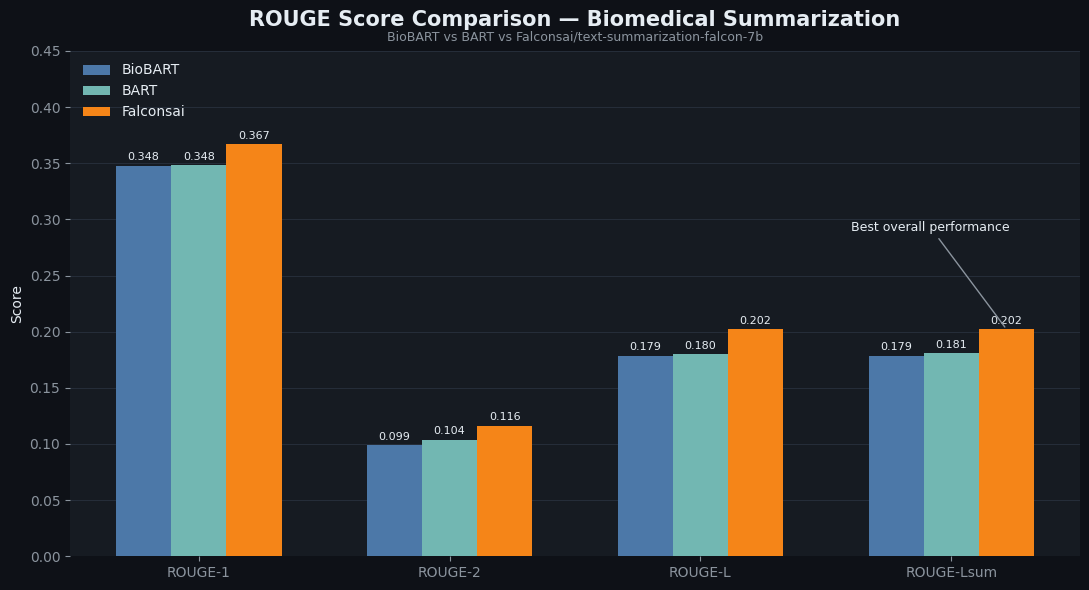

In [28]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────────────────
# ROUGE results
# ─────────────────────────────────────────────────────
scores = {
    "BioBART": {
        "rouge1": 0.3480,
        "rouge2": 0.0992,
        "rougeL": 0.1787,
        "rougeLsum": 0.1788
    },
    "BART": {
        "rouge1": 0.3484,
        "rouge2": 0.1037,
        "rougeL": 0.1802,
        "rougeLsum": 0.1806
    },
    "Falconsai": {
        "rouge1": 0.3669,
        "rouge2": 0.1164,
        "rougeL": 0.2022,
        "rougeLsum": 0.2022
    }
}

models = list(scores.keys())
metrics = ["rouge1", "rouge2", "rougeL", "rougeLsum"]

metric_labels = {
    "rouge1": "ROUGE-1",
    "rouge2": "ROUGE-2",
    "rougeL": "ROUGE-L",
    "rougeLsum": "ROUGE-Lsum"
}

# ─────────────────────────────────────────────────────
# Styling
# ─────────────────────────────────────────────────────
BG = "#0E1117"
PANEL = "#161B22"
GRID = "#2A3441"
TEXT = "#E6EDF3"
SUBTEXT = "#8B949E"

COLORS = {
    "BioBART": "#4C78A8",
    "BART": "#72B7B2",
    "Falconsai": "#F58518"
}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": PANEL,
    "axes.edgecolor": PANEL,
    "axes.labelcolor": TEXT,
    "xtick.color": SUBTEXT,
    "ytick.color": SUBTEXT,
    "text.color": TEXT,
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold"
})

# ─────────────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(metrics))
width = 0.22

# Bars
for i, model in enumerate(models):
    vals = [scores[model][m] for m in metrics]

    bars = ax.bar(
        x + (i - 1) * width,
        vals,
        width=width,
        label=model,
        color=COLORS[model],
        linewidth=0
    )

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.003,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=TEXT
        )

# ─────────────────────────────────────────────────────
# Axes / labels
# ─────────────────────────────────────────────────────
ax.set_title(
    "ROUGE Score Comparison — Biomedical Summarization",
    fontsize=15,
    pad=18
)

ax.text(
    0.5,
    1.02,
    "BioBART vs BART vs Falconsai/text-summarization-falcon-7b",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    color=SUBTEXT
)

ax.set_xticks(x)
ax.set_xticklabels([metric_labels[m] for m in metrics], fontsize=10)

ax.set_ylabel("Score", fontsize=10)

ax.set_ylim(0, 0.45)

# Grid
ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.6,
    color=GRID,
    alpha=0.9
)

ax.set_axisbelow(True)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend
legend = ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left"
)

for text in legend.get_texts():
    text.set_color(TEXT)

# Highlight best model subtly
best_model = "Falconsai"

ax.annotate(
    "Best overall performance",
    xy=(3 + width, scores[best_model]["rougeLsum"]),
    xytext=(2.6, 0.29),
    fontsize=9,
    color=TEXT,
    arrowprops=dict(
        arrowstyle="-",
        color=SUBTEXT,
        lw=1
    )
)

plt.tight_layout()
plt.show()

---

Metrics Evaluation: ROUGE x Qualitative Analysis

The evaluation results show that summarization quality is not only about generating medically correct language, but also about understanding which information matters most in a scientific narrative. While the ROUGE metrics provide a numerical measure of overlap between generated summaries and the original abstracts, the qualitative examples reveal how each model interprets and reorganizes information at a communicative level.

Across all ROUGE metrics, Falconsai/medical_summarization obtained the strongest performance. This becomes visible in the qualitative samples as well. In many cases, the model was more successful at identifying the central clinical event or research contribution instead of remaining focused on broad background information. In Sample 1, for example, the reference abstract revolves around a missed chemotherapy complication that was initially attributed to anesthesia. Falconsai captures this communicative intention more directly than the other models, which spend most of their summaries explaining general oncology procedures rather than the actual clinical incident.

This relationship between ROUGE and qualitative interpretation is important. Higher ROUGE-1 scores indicate that the generated summary contains many of the same key medical terms and concepts as the reference text. However, the examples demonstrate that lexical overlap alone does not guarantee a meaningful summary. Both BioBART and BART frequently reproduce medically relevant vocabulary while failing to preserve the communicative focus of the article. In discourse terms, they often maintain the “topic” of the text without preserving its “message”.

The ROUGE-2 and ROUGE-L metrics help explain this difference further. These metrics reward phrase continuity and structural similarity, which are closely tied to how humans perceive coherence. Falconsai achieved stronger results in both categories because its summaries more consistently followed the same informational progression as the reference abstracts. Even when the model produced imperfect or truncated sentences, it usually retained the central argumentative structure of the article: problem, intervention, and outcome.

The qualitative outputs also expose the limitations of automated summarization metrics. Several summaries with relatively acceptable ROUGE values still contained hallucinations, fragmented sentences, or irrelevant additions. In Sample 2, for instance, BART introduces unrelated references to PTSD, despite the article focusing on spinal epidural lipomatosis. Similarly, Falconsai occasionally inserts fabricated clinical details or abruptly unfinished statements. These artifacts demonstrate that a model can achieve lexical similarity while still generating linguistically unstable or factually unreliable content.

Another recurring pattern is the influence of the chunking pipeline. Because long articles were divided into fixed token segments before summarization, some models overemphasized introductory material and lost critical conclusions appearing later in the text. This explains why several summaries appear informative at first glance but fail to communicate the actual contribution of the case report or study. From a discourse perspective, the models often preserve local semantic information while struggling with global narrative organization.

Overall, the results suggest that biomedical summarization is not simply a problem of compressing information, but also one of preserving communicative intent. The strongest model was not necessarily the one with the most technical vocabulary, but the one that better maintained the informational hierarchy of the original abstracts. Combining quantitative evaluation with qualitative linguistic analysis therefore provides a more complete understanding of summarization performance than ROUGE scores alone.


Disclaimer:

The current results should not be interpreted as the final stage of development, but rather as the point at which a professional evaluation process begins to inform the next iteration of the system.

In this project, the qualitative outputs suggest that the primary bottleneck is not necessarily the language models themselves, but the chunking and aggregation strategy used to process long biomedical documents. Several summaries preserved local terminology while losing the broader narrative structure or central clinical contribution of the article, indicating that information fragmentation occurs before generation. For this reason, the next logical iteration would focus on improving chunk segmentation, overlap strategy, and summary aggregation in order to preserve discourse continuity and informational hierarchy more effectively across long-form scientific texts.


---

Gradio Demo:

In [29]:
import gradio as gr
from transformers import pipeline

# Load summarization model (swap with your chosen one)
summarizer = pipeline("summarization", model="Falconsai/medical_summarization")

# Core function
def summarize_text(text, max_len, min_len):
    if not text.strip():
        return ""
    result = summarizer(text, max_length=max_len, min_length=min_len, do_sample=False)
    return result[0]['summary_text']

# Custom CSS for bioinformatics aesthetic
custom_css = """
body {
    background: linear-gradient(135deg, #0f172a, #020617);
    color: #e2e8f0;
    font-family: 'Courier New', monospace;
}
textarea {
    background-color: #020617 !important;
    color: #38bdf8 !important;
    border: 1px solid #334155 !important;
}
button {
    background-color: #22c55e !important;
    color: black !important;
    border-radius: 8px !important;
}
"""

with gr.Blocks(css=custom_css) as demo:
    gr.Markdown("""
    # 🧬 Genomic Insight Summarizer
    ### Transformer-based biomedical text condensation
    """)

    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(
                lines=15,
                label="Input Scientific Text",
                placeholder="Paste biomedical or genomic text here..."
            )

            max_len = gr.Slider(50, 300, value=150, step=10, label="Max Summary Length")
            min_len = gr.Slider(10, 100, value=40, step=5, label="Min Summary Length")

            submit_btn = gr.Button("Run Summarization")

        with gr.Column():
            output_text = gr.Textbox(
                lines=15,
                label="Summary Output"
            )

    submit_btn.click(
        summarize_text,
        inputs=[input_text, max_len, min_len],
        outputs=output_text
    )

if __name__ == "__main__":
    demo.launch()


/tmp/ipykernel_788/3838491721.py:33: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d0960fd7080cb25484.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
